In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# -----------------------------
# Función multimodal de aptitud
# -----------------------------
def fitness(x):
    return (
        8  * np.exp(-(x + 4)**2)
        + 12 * np.exp(-0.7 * (x - 1)**2)
        + 7  * np.exp(-0.5 * (x - 6)**2)
    )

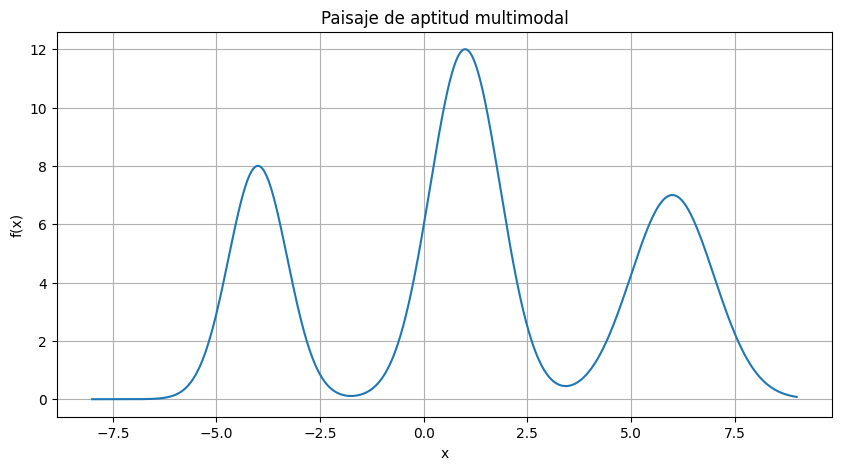

In [10]:
# -----------------------------
# Gráfica inicial del paisaje
# -----------------------------
x = np.linspace(-8, 9, 1000)
y = fitness(x)

plt.figure(figsize=(10, 5))
plt.plot(x, y)
plt.title("Paisaje de aptitud multimodal")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.show()

In [3]:
# -----------------------------
# Fitness sharing
# -----------------------------
def sharing_distance(d, sigma=1.5, alpha=1):
    if d < sigma:
        return 1 - (d / sigma)**alpha
    return 0

def shared_fitness(pop, sigma=1.5):
    raw = fitness(pop)
    shared = np.zeros_like(raw)

    for i, x in enumerate(pop):
        niche_count = 0
        for y in pop:
            niche_count += sharing_distance(abs(x - y), sigma)
        shared[i] = raw[i] / niche_count

    return shared

In [4]:
# -----------------------------
# Selección proporcional
# -----------------------------
def select(pop, fit_values):
    probs = fit_values / np.sum(fit_values)
    indices = np.random.choice(len(pop), size=len(pop), p=probs)
    return pop[indices]

In [5]:
# -----------------------------
# Cruce aritmético
# -----------------------------
def crossover(pop, pc=0.8):
    new_pop = []

    np.random.shuffle(pop)

    for i in range(0, len(pop), 2):
        p1 = pop[i]
        p2 = pop[i + 1]

        if np.random.rand() < pc:
            a = np.random.rand()
            h1 = a * p1 + (1 - a) * p2
            h2 = a * p2 + (1 - a) * p1
        else:
            h1, h2 = p1, p2

        new_pop.extend([h1, h2])

    return np.array(new_pop)

In [6]:

# -----------------------------
# Mutación gaussiana
# -----------------------------
def mutate(pop, pm=0.2, sigma_mut=0.3):
    for i in range(len(pop)):
        if np.random.rand() < pm:
            pop[i] += np.random.normal(0, sigma_mut)

    return np.clip(pop, -8, 9)


In [7]:
# -----------------------------
# Algoritmo genético
# -----------------------------
def run_ga(use_sharing=True, generations=80, mu=60):
    pop = np.random.uniform(-8, 9, mu)

    history = []

    for t in range(generations):
        if use_sharing:
            fit_values = shared_fitness(pop, sigma=1.5)
        else:
            fit_values = fitness(pop)

        history.append(pop.copy())

        selected = select(pop, fit_values)
        crossed = crossover(selected)
        pop = mutate(crossed)

    return pop, history


In [8]:
# -----------------------------
# Ejecutar ambos casos
# -----------------------------
np.random.seed(42)

pop_normal, hist_normal = run_ga(use_sharing=False)
pop_sharing, hist_sharing = run_ga(use_sharing=True)


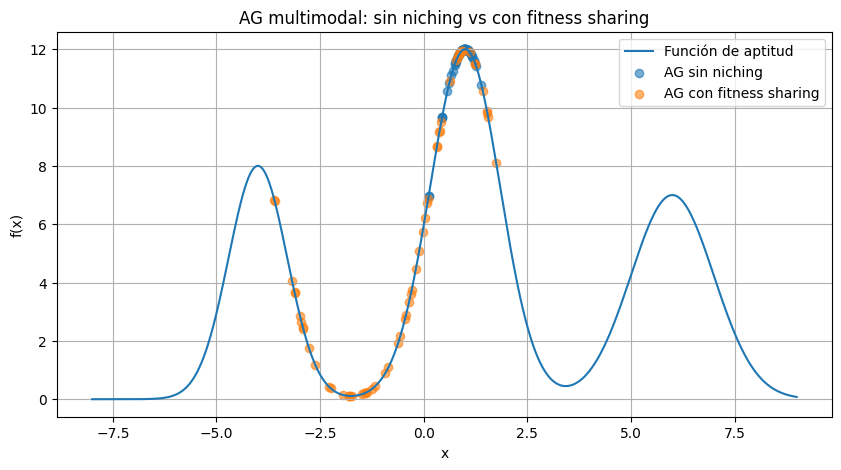

In [9]:
# -----------------------------
# Gráfica final
# -----------------------------
x = np.linspace(-8, 9, 1000)
y = fitness(x)

plt.figure(figsize=(10, 5))
plt.plot(x, y, label="Función de aptitud")

plt.scatter(pop_normal, fitness(pop_normal), alpha=0.6, label="AG sin niching")
plt.scatter(pop_sharing, fitness(pop_sharing), alpha=0.6, label="AG con fitness sharing")

plt.title("AG multimodal: sin niching vs con fitness sharing")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()